## Graph Notebook Map (What each function does)

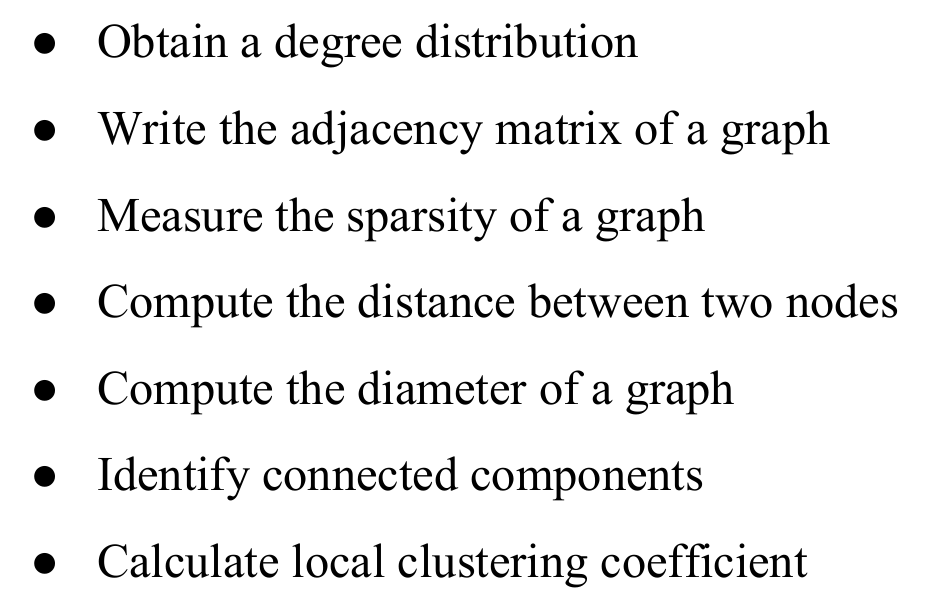

**Input (only once)**
- `G_nx = nx.karate_club_graph()` → just to get raw nodes/edges

In [ ]:
# NOTE: We'll avoid using any networkx algorithms other than loading nodes/edges.
import networkx as nx
from functions_graphs__basic import *
# Load the Zachary Karate Club graph as our input graph (undirected)
G_nx = nx.karate_club_graph()

# Freeze node labels as integers 0..N-1 (karate already is)
nodes = sorted(list(G_nx.nodes()))
edges = [(int(u), int(v)) for u, v in G_nx.edges()]  # undirected edges

N = len(nodes)
L = len(edges)

print(f"Nodes: {N}, Edges: {L}")

Nodes: 34, Edges: 78


In [2]:
# Tiny debug helpers (pretty printers + toggle)
DEBUG = True

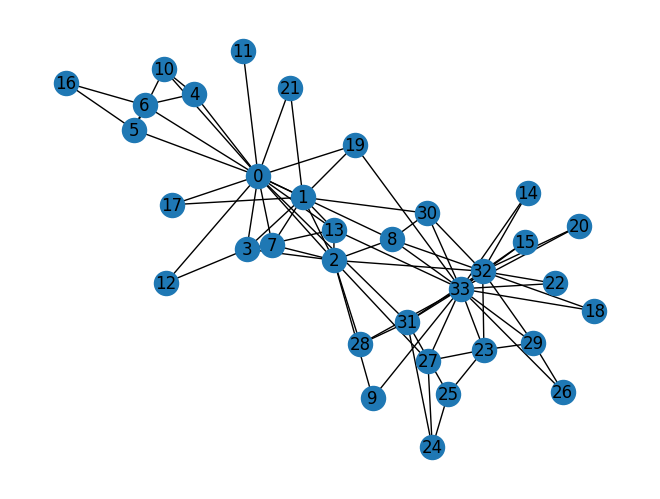

In [3]:
import matplotlib.pyplot as plt
nx.draw(G_nx, with_labels=True)
plt.show()

**Build (from scratch)**

In [4]:
# We'll keep both an adjacency list (dict of sets) and an adjacency matrix (list of lists).

adj, A, idx = build_adj_undirected(nodes, edges)

print("Adjacency list built. Example (first 3 nodes):")
for n in nodes[:3]:
    print(n, "->", sorted(adj[n]))


Adjacency list built. Example (first 3 nodes):
0 -> [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
1 -> [0, 2, 3, 7, 13, 17, 19, 21, 30]
2 -> [0, 1, 3, 7, 8, 9, 13, 27, 28, 32]


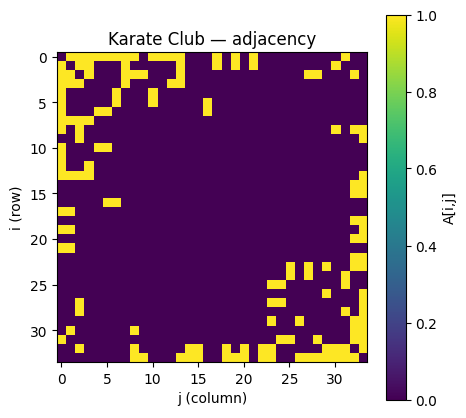

In [5]:
# Tip: on large graphs this helps you "see" sparsity and structure.

plot_adjacency_matrix(A, "Karate Club — adjacency")

### Degree & Distribution


── Degree distribution (numeric) ────────────────────────────────────────────────────────────
k= 1  P(k)=0.0294  count=1
k= 2  P(k)=0.3235  count=11
k= 3  P(k)=0.1765  count=6
k= 4  P(k)=0.1765  count=6
k= 5  P(k)=0.0882  count=3
k= 6  P(k)=0.0588  count=2
k= 9  P(k)=0.0294  count=1
k=10  P(k)=0.0294  count=1
k=12  P(k)=0.0294  count=1
k=16  P(k)=0.0294  count=1
k=17  P(k)=0.0294  count=1


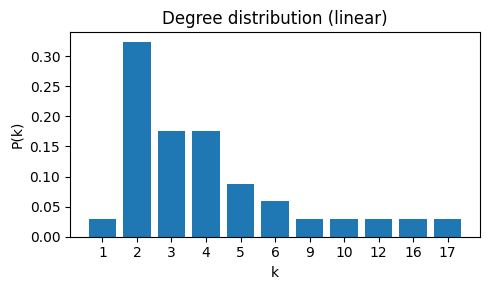

In [6]:
# Now compute degree sequence and distribution, and plot it.
deg_seq = degree_sequence(adj, nodes)
deg_dist = degree_distribution(adj, nodes)
plot_degree_distribution(adj, nodes)

### Density / Sparsity

In [7]:
# Density (undirected, no self-loops) = 2L / (N*(N-1))
# Sparsity = 1 - Density

print("Density:", density_undirected(N, L))
print("Sparsity:", sparsity_undirected(N, L))

Density: 0.13903743315508021
Sparsity: 0.8609625668449198



### Shortest Paths (BFS)

In [8]:
dist, parent, snaps = bfs_trace(adj, 0, target=33)
pretty_play_bfs(snaps)

# reconstruct the path 0 -> 33 from parent map
hr("Shortest path 0 → 33")
print(reconstruct_path(parent, 0, 33))



── Step 0: init ────────────────────────────────────────────────────────────
queue: [0]
visited: {0}
parent: {0:None}
dist: {0:0}

── Step 1: pop ────────────────────────────────────────────────────────────
queue: []
visited: {0}
parent: {0:None}
dist: {0:0}

── Step 2: discover 1 via 0 ────────────────────────────────────────────────────────────
queue: [1]
visited: {0, 1}
parent: {0:None, 1:0}
dist: {0:0, 1:1}

── Step 3: discover 2 via 0 ────────────────────────────────────────────────────────────
queue: [1, 2]
visited: {0, 1, 2}
parent: {0:None, 1:0, 2:0}
dist: {0:0, 1:1, 2:1}

── Step 4: discover 3 via 0 ────────────────────────────────────────────────────────────
queue: [1, 2, 3]
visited: {0, 1, 2, 3}
parent: {0:None, 1:0, 2:0, 3:0}
dist: {0:0, 1:1, 2:1, 3:1}

── Step 5: discover 4 via 0 ────────────────────────────────────────────────────────────
queue: [1, 2, 3, 4]
visited: {0, 1, 2, 3, 4}
parent: {0:None, 1:0, 2:0, 3:0, 4:0}
dist: {0:0, 1:1, 2:1, 3:1, 4:1}

── Step 6: discover

**Breadth-First Search (BFS) — What happens in the trace**

**Goal.** Find the shortest path from source `0` to target `33` in an *unweighted* graph.

**Init.**  
- `queue = [0]` (frontier to expand, FIFO)  
- `visited = {0}` (avoid reprocessing)  
- `parent = {0: None}` (to rebuild the path)  
- `dist = {0: 0}` (hop count from source)

**Expand 0 (first layer).**  
Dequeue `0` to inspect its neighbors. For each unseen neighbor `v` of `0`:  
- mark `v` visited, set `parent[v] = 0`, `dist[v] = 1`, and enqueue `v`.  
This creates the **first BFS layer** (distance 1):  
`{1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31}`.

**Expand first-layer nodes (second layer).**  
Dequeue nodes in FIFO order (`1, 2, 3, 4, 5, 6, 7, 8, ...`).  
Each expansion may discover new nodes at **distance 2**:
- From `1` → discover `30` (`parent[30]=1`, `dist[30]=2`).  
- From `2` → discover `9, 27, 28, 32` (all `dist=2`, `parent=2`).  
- From `5` → discover `16` (`dist[16]=2`, `parent[16]=5`).  
- From `8` → discover **`33`** (`dist[33]=2`, `parent[33]=8`).

**Early stop (target reached).**  
As soon as `33` is discovered, BFS guarantees the found distance (`2`) is **minimal** (BFS explores by nondecreasing distance in unweighted graphs). You can stop exploring.

**Path reconstruction.**  
Follow `parent` pointers from the target back to the source and reverse:  
`33 → 8 → 0` → **Shortest path: `[0, 8, 33]`** with **length 2**.

### Diameter

In [9]:
hr("Diameter computation (progress)")
diam, far_pair = diameter_with_progress(adj, nodes)
print(f"Diameter = {diam}, example far pair = {far_pair}")



── Diameter computation (progress) ────────────────────────────────────────────────────────────
progress: source= 0  ecc= 3  current_diam= 3  far_pair=(0, 14)
progress: source= 5  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=10  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=15  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=20  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=25  ecc= 4  current_diam= 5  far_pair=(14, 16)
progress: source=30  ecc= 4  current_diam= 5  far_pair=(14, 16)
Diameter = 5, example far pair = (14, 16)


**Diameter computation — how to read the progress**

- **ecc** = *eccentricity* of the current **source** node:  
  the longest shortest-path distance from that source to any node.

- **current_diam** = running maximum of eccentricities seen so far:  
  \[
  \text{current\_diam} = \max_{s \in \text{processed sources}} \ \text{ecc}(s)
  \]

- **far_pair** = an *example* node pair that realizes the current diameter  
  (two nodes whose shortest-path distance equals `current_diam`).

**Your trace, step by step (sampling sources 0,5,10,15,20,25,30):**
- From `0`: `ecc=3` → `current_diam=3`, far pair `(0,14)`.
- From `5`: `ecc=4` → update `current_diam=4`, far pair `(4,14)`.
- From `10`: `ecc=4` → diameter unchanged.
- From `15`: `ecc=5` → update `current_diam=5`, far pair `(14,16)`.
- From `20, 25, 30`: `ecc≤5` → diameter stays **5**.

**Result.**  
**Diameter = 5**. The pair `(14, 16)` is one valid *peripheral pair* at distance 5 (there can be multiple such pairs).

**Why this works.**  
For each source, run BFS (unweighted graph) to get all shortest-path lengths; the maximum of those is the eccentricity. The **graph diameter** is the maximum eccentricity over nodes. Your routine keeps the max as it goes and stores one witnessing pair.

**Notes.**
- Multiple pairs may realize the diameter; the algorithm reports one.
- Complexity: each BFS is \(O(N+L)\); with sampled \(k\) sources, total \(O(k(N+L))\). A full exact sweep uses \(k=N\).

### Connected Components

In [10]:
cc, steps = connected_components_trace(adj, nodes)
play_components_steps(steps)
hr("Connected components")
for i, c in enumerate(cc, 1):
    print(f"Comp {i} (size={len(c)}): {c}")


── CC Step 0: start_component ────────────────────────────────────────────────────────────
payload: 0
stack: [0]
seen: {0}

── CC Step 1: visit ────────────────────────────────────────────────────────────
payload: 0
stack: []
seen: {0}

── CC Step 2: discover ────────────────────────────────────────────────────────────
payload: (0, 1)
stack: [1]
seen: {0, 1}

── CC Step 3: discover ────────────────────────────────────────────────────────────
payload: (0, 2)
stack: [1, 2]
seen: {0, 1, 2}

── CC Step 4: discover ────────────────────────────────────────────────────────────
payload: (0, 3)
stack: [1, 2, 3]
seen: {0, 1, 2, 3}

── CC Step 5: discover ────────────────────────────────────────────────────────────
payload: (0, 4)
stack: [1, 2, 3, 4]
seen: {0, 1, 2, 3, 4}

── CC Step 6: discover ────────────────────────────────────────────────────────────
payload: (0, 5)
stack: [1, 2, 3, 4, 5]
seen: {0, 1, 2, 3, 4, 5}

── CC Step 7: discover ──────────────────────────────────────────────────────

**Connected Components via Iterative DFS — Reading the Trace**

**Goal.** Enumerate all nodes reachable from a start node and group them into connected components (here: the whole graph).

**Data structures (invariants).**
- `stack` — LIFO frontier for DFS.
- `seen` — nodes already discovered (prevents revisits).
- `payload` — what the step operated on (node visit or (u,v) discovery).

---

### What the steps mean

- **CC Step 0: `start_component`**
  - Seed a new component with the chosen start node `0`.
  - Initialize: `stack=[0]`, `seen={0}`.

- **CC Step 1: `visit` (node popped)**
  - Pop `0` from the stack to expand it.

- **CC Steps 2–17: `discover` (edges from 0)**
  - For each neighbor `v` of `0`, if `v ∉ seen`, mark it seen and **push** it.
  - After processing `0`, the stack holds **all** neighbors of `0` in the order they were pushed:
    `[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]`.

- **Key DFS behavior (LIFO):**
  - DFS explores **the last pushed neighbor first**.  
  - Hence next `visit` is **31** (Step 18), not 1.

- **From 31 (Steps 19–23):**
  - Discover its unseen neighbors `24, 25, 28, 32, 33` (each pushed).

- **Visit order (Steps 24 onward):**
  - Pop **33** (last pushed among 31’s neighbors) and visit it.
  - From **33**, discover a big batch of new nodes (`9,14,15,18,20,22,23,26,27,29,30, ...`) and push them.
  - Then continue popping in strict LIFO order: `30, 29, 27, 26, 23, 22, 20, 18, 15, 14, 9, 32, 28, 25, 24, 21, 19, 17, 13, 12, 11, 10, 8, 7, 6, 16, 5, 4, 3, 2, 1`.

- **CC Step 68: `finish_component`**
  - The component is finished when the stack empties.
  - The listed payload is the **finishing order** (the order nodes were popped/finished), which naturally looks “reverse-deep” due to LIFO.

---

### Interpretation & result

- **Why everything lands in one component?**  
  Every node becomes `seen` through chained discoveries; no gaps remain.  
  **Connected components:** `Comp 1 (size=34)` includes all nodes `0…33`.

- **Mental model.**  
  Iterative DFS = “go deep via last-pushed neighbor; backtrack when stuck.”  
  Pushing many neighbors early (like from node 0) **doesn’t** make the search broad; the **pop order** controls depth.

- **Complexity.**  
  Each vertex and edge is processed O(1) amortized → **O(N + L)**.

### Clustering

In [11]:
for n in [0, 1, 33]:
    explain_local_clustering(adj, n)



── Node 0 — neighbors and pairs ────────────────────────────────────────────────────────────
neighbors: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
pair (1,2)  connected=True
pair (1,3)  connected=True
pair (1,4)  connected=False
pair (1,5)  connected=False
pair (1,6)  connected=False
pair (1,7)  connected=True
pair (1,8)  connected=False
pair (1,10)  connected=False
pair (1,11)  connected=False
pair (1,12)  connected=False
pair (1,13)  connected=True
pair (1,17)  connected=True
pair (1,19)  connected=True
pair (1,21)  connected=True
pair (1,31)  connected=False
pair (2,3)  connected=True
pair (2,4)  connected=False
pair (2,5)  connected=False
pair (2,6)  connected=False
pair (2,7)  connected=True
pair (2,8)  connected=True
pair (2,10)  connected=False
pair (2,11)  connected=False
pair (2,12)  connected=False
pair (2,13)  connected=True
pair (2,17)  connected=False
pair (2,19)  connected=False
pair (2,21)  connected=False
pair (2,31)  connected=False
pair (3,4)  connected

**Local Clustering Coefficient — Example Interpretation**

We are analyzing the *local clustering coefficient* $C_i$ for selected nodes in a graph.

The **clustering coefficient** of node *i* measures how connected its neighbors are to each other.  
Formally:
$$
C_i = \frac{2 \times E_i}{k_i (k_i - 1)}
$$
where:
- $k_i$ = degree of node *i* (number of neighbors),
- $E_i$ = number of existing edges among those neighbors.

---

**Node 0**
- Neighbors: 16 nodes  
- Pairs among neighbors: $\frac{16(16-1)}{2} = 120$
- Connected pairs (edges among neighbors): 18  
- Clustering coefficient:  
  $$
  C_0 = \frac{2 \times 18}{16 \times 15} = 0.15
  $$
→ **Moderate clustering:** 15% of possible neighbor pairs are connected.

---

**Node 1**
- Neighbors: 9 nodes  
- Pairs among neighbors: $\frac{9(9-1)}{2} = 36$  
- Connected pairs: 12  
- Clustering coefficient:  
  $$
  C_1 = \frac{2 \times 12}{9 \times 8} = 0.33
  $$
→ **High clustering:** One-third of all possible neighbor pairs are connected — node 1 lies in a locally dense region.

---

**Node 33**
- Neighbors: 17 nodes  
- Pairs among neighbors: $\frac{17(17-1)}{2} = 136$
- Connected pairs: 15  
- Clustering coefficient:  
  $$
  C_{33} = \frac{2 \times 15}{17 \times 16} \approx 0.11
  $$
→ **Low clustering:** Only ~11% of possible neighbor pairs connect, meaning node 33 links to nodes that are mostly unconnected to each other.

---

**Summary Table**

| Node | Degree \(k_i\) | Neighbor Pairs | Edges Among Neighbors \(E_i\) | \(C_i\) | Interpretation |
|------|----------------|----------------|--------------------------------|----------|----------------|
| 0 | 16 | 120 | 18 | 0.15 | Moderate local cohesion |
| 1 | 9 | 36 | 12 | 0.33 | Highly clustered neighborhood |
| 33 | 17 | 136 | 15 | 0.11 | Sparse, weakly connected neighborhood |

**Insight:**  
The local clustering coefficient captures *how close a node’s neighbors are to forming a clique.*  
- High \( C_i \): locally dense community.  
- Low \( C_i \): node connects otherwise unconnected regions — potential **bridge** or **hub** role.
